### Procesamiento de Lenguaje Natural I
# **Desafío 1**



In [1]:
%pip install numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


### Vectorización de texto y modelo de clasificación Naïve Bayes con el dataset 20 newsgroups

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score

Utilizamos **20newsgroups** por ser un dataset clásico de NLP ya viene incluido y formateado en sklearn

In [3]:
from sklearn.datasets import fetch_20newsgroups
import numpy as np

## Carga de datos

Cargamos los datos (ya separados de forma predeterminada en train y test)

El dataset 20 Newsgroups contiene aproximadamente 18 000 publicaciones de grupos de noticias distribuidas en 20 temas. Está dividido en dos subconjuntos: uno para entrenamiento (train set) y otro para pruebas (test set).

In [4]:
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

## Vectorización

Instanciamos un vectorizador.

Podemos ver diferentes parámetros de instanciación en la documentación de sklearn https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [14]:
tfidfvect = TfidfVectorizer()

En el atributo `data` accedemos al texto

In [15]:
print(newsgroups_train.data[2])

well folks, my mac plus finally gave up the ghost this weekend after
starting life as a 512k way back in 1985.  sooo, i'm in the market for a
new machine a bit sooner than i intended to be...

i'm looking into picking up a powerbook 160 or maybe 180 and have a bunch
of questions that (hopefully) somebody can answer:

* does anybody know any dirt on when the next round of powerbook
introductions are expected?  i'd heard the 185c was supposed to make an
appearence "this summer" but haven't heard anymore on it - and since i
don't have access to macleak, i was wondering if anybody out there had
more info...

* has anybody heard rumors about price drops to the powerbook line like the
ones the duo's just went through recently?

* what's the impression of the display on the 180?  i could probably swing
a 180 if i got the 80Mb disk rather than the 120, but i don't really have
a feel for how much "better" the display is (yea, it looks great in the
store, but is that all "wow" or is it really th

Con la interfaz habitual de sklearn podemos ajustar el vectorizador (obtener el vocabulario y calcular el vector IDF) y transformar directamente los datos.

Podemos denominar `X_train` como la matriz documento-término.

In [16]:
X_train = tfidfvect.fit_transform(newsgroups_train.data)

Recordemos que las vectorizaciones por conteos son de tipo sparse, por ello sklearn convenientemente devuelve los vectores de documentos como matrices de tipo sparse.

In [17]:
print(type(X_train))
print(f'shape: {X_train.shape}')
print(f'Cantidad de documentos: {X_train.shape[0]}')
print(f'Tamaño del vocabulario (dimensionalidad de los vectores): {X_train.shape[1]}')

<class 'scipy.sparse._csr.csr_matrix'>
shape: (11314, 101631)
Cantidad de documentos: 11314
Tamaño del vocabulario (dimensionalidad de los vectores): 101631


Una vez ajustado el vectorizador, podemos acceder a atributos como el vocabulario aprendido. Es un diccionario que va de términos a índices.

El índice es la posición en el vector de documento.

In [18]:
tfidfvect.vocabulary_['car']

25775

Probamos con una palbra que no está en el documento.

In [19]:
# tfidfvect.vocabulary_['cocoliso']

Es muy útil tener el diccionario opuesto que va de índices a términos

In [20]:
idx2word = {v: k for k,v in tfidfvect.vocabulary_.items()}

En `y_train` guardamos los targets que son enteros

In [21]:
y_train = newsgroups_train.target
y_train[:10]

array([ 7,  4,  4,  1, 14, 16, 13,  3,  2,  4])

Hay 20 clases correspondientes a los 20 grupos de noticias

In [22]:
print(f'clases {np.unique(newsgroups_test.target)}')
newsgroups_test.target_names

clases [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


['alt.atheism',
 'comp.graphics',
 'comp.os.ms-windows.misc',
 'comp.sys.ibm.pc.hardware',
 'comp.sys.mac.hardware',
 'comp.windows.x',
 'misc.forsale',
 'rec.autos',
 'rec.motorcycles',
 'rec.sport.baseball',
 'rec.sport.hockey',
 'sci.crypt',
 'sci.electronics',
 'sci.med',
 'sci.space',
 'soc.religion.christian',
 'talk.politics.guns',
 'talk.politics.mideast',
 'talk.politics.misc',
 'talk.religion.misc']

## Similaridad de documentos

Veamos similaridad de documentos. Tomemos algún documento

In [ ]:
idx = 4811
print(newsgroups_train.data[idx])

THE WHITE HOUSE

                  Office of the Press Secretary
                   (Pittsburgh, Pennslyvania)
______________________________________________________________
For Immediate Release                         April 17, 1993     

             
                  RADIO ADDRESS TO THE NATION 
                        BY THE PRESIDENT
             
                Pittsburgh International Airport
                    Pittsburgh, Pennsylvania
             
             
10:06 A.M. EDT
             
             
             THE PRESIDENT:  Good morning.  My voice is coming to
you this morning through the facilities of the oldest radio
station in America, KDKA in Pittsburgh.  I'm visiting the city to
meet personally with citizens here to discuss my plans for jobs,
health care and the economy.  But I wanted first to do my weekly
broadcast with the American people. 
             
             I'm told this station first broadcast in 1920 when
it reported that year's presidential elec

Medimos la similaridad coseno con todos los documentos de train

In [ ]:
cossim = cosine_similarity(X_train[idx], X_train)[0]

Podemos ver los valores de similaridad ordenados de mayor a menor

In [ ]:
np.sort(cossim)[::-1]

array([1.        , 0.70930477, 0.67474953, ..., 0.        , 0.        ,
       0.        ])

Después vemos a qué documentos corresponden

In [ ]:
np.argsort(cossim)[::-1]

array([4811, 6635, 4253, ..., 9019, 9016, 8748])

Obtenemos los 5 documentos más similares:

In [ ]:
mostsim = np.argsort(cossim)[::-1][1:6]
print(mostsim)

[6635 4253 3596 4271 3746]


El documento original pertenece a la clase:

In [ ]:
newsgroups_train.target_names[y_train[idx]]

'talk.politics.misc'

Revisamos las clases de los 5 más similares:

In [ ]:
for i in mostsim:
  print(newsgroups_train.target_names[y_train[i]])

talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc
talk.politics.misc


### Modelo de clasificación Naïve Bayes

Instanciamos el modelo de clasificación Naive Bayes y lo entrenamos con sklearn

In [ ]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

MultinomialNB()

Ya tenemos nuestro vectorizador ya ajustado en train, vectorizamos los textos
del conjunto de test.

In [ ]:
X_test = tfidfvect.transform(newsgroups_test.data)
y_test = newsgroups_test.target
y_pred =  clf.predict(X_test)

El F1-score es una métrica adecuada para evaluar el desempeño de modelos de clasificación, especialmente cuando existe desbalance entre clases.

* El promediado macro calcula el promedio del F1-score de cada clase, otorgando el mismo peso a todas las clases.
* El promediado micro calcula las métricas de forma global considerando todas las predicciones; en problemas de clasificación multiclase suele ser equivalente a la accuracy, por lo que no es la mejor métrica cuando el dataset está desbalanceado.

In [ ]:
f1_score(y_test, y_pred, average='macro')

0.5854345727938506

---

## **Consigna del Desafío 1**
**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado.**



**1. Vectorizar documentos**
* Tomar 5 documentos al azar y medir similaridad con el resto de los documentos.
Estudiar los 5 documentos más similares de cada uno analizar si tiene sentido
la similaridad según el contenido del texto y la etiqueta de clasificación.

**2. Construir un modelo de clasificación por prototipos (tipo zero-shot).**
* Clasificar los documentos de un conjunto de test comparando cada uno con todos los de entrenamiento y asignar la clase al label del documento del conjunto de entrenamiento con mayor similaridad.

**3. Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación**

* F1-Score Macro en el conjunto de datos de test. Considerar cambiar parámetros
de instanciación del vectorizador y los modelos y probar modelos de Naïve Bayes Multinomial y ComplementNB.

**NO cambiar el hiperparámetro ngram_range de los vectorizadores**.

**4. Transponer la matriz documento-término.**
* De esa manera se obtiene una matriz término-documento que puede ser interpretada como una colección de vectorización de palabras.
* Estudiar ahora similaridad entre palabras tomando 5 palabras y estudiando sus 5 más similares.

**Elegir las palabras MANUALMENTE para evitar la aparición de términos poco interpretables**.


#### Punto 1

**1. Vectorizar documentos**
* Tomar 5 documentos al azar y medir similaridad con el resto de los documentos.
Estudiar los 5 documentos más similares de cada uno analizar si tiene sentido
la similaridad según el contenido del texto y la etiqueta de clasificación.

In [ ]:
# Seleccionar documentos al azar
import random
import numpy as np

random.seed(2026) # para reproducibilidad

# Seleccionar 5 documentos
indices = random.sample(range(1,len(newsgroups_train.data)), 5)

# docs = []
# # for idx in indices:
# #   docs.append(newsgroups_train.data[idx])


# Bucle para almacenar todo en un diccionario

# cossims = {}
# for idx in indices:
#   print(f'Documento: {idx} - Clase: {newsgroups_train.target_names[y_train[idx]]}')
#   print('Contenido:')
#   print(newsgroups_train.data[idx])
#   print('')
#   cossims[idx] = cosine_similarity(X_train[idx], X_train)[0]

#   # Top 5 (indices) del documento idx
#   docs_sim_idx = np.argsort(cossims[idx])[::-1][1:6]
#   # Top 5 (similitudes) del documento idx
#   cossims[idx] = np.sort(cossims[idx])[::-1] # Orden de mayor a menor

#   # Se obtiene los 5 documentos mas similares para cada uno y su clasificacion
#   print(f'Documentos mas similares:')
#   for i, doc in enumerate(docs_sim_idx):
#     print(f'\nDocumento: {docs_sim_idx[i]} - Similaridad: {cossims[idx][i+1]:.4f} Clase: {newsgroups_train.target_names[y_train[doc]]}')
#     print('Contenido:')
#     print(newsgroups_train.data[doc])
#     print("-"*100)

#   print("="*50)
#   print('')

##### Analisis documento 1

In [ ]:
idx = indices[0]

print(f'Documento: {idx} - Clase: {newsgroups_train.target_names[y_train[idx]]}')
print('Contenido:')
print(newsgroups_train.data[idx])
print('')
cossims = cosine_similarity(X_train[idx], X_train)[0]

# Top 5 (indices) del documento idx
docs_sim_idx = np.argsort(cossims)[::-1][1:6]
# Top 5 (similitudes) del documento idx
cossims = np.sort(cossims)[::-1] # Orden de mayor a menor

print(docs_sim_idx)
print(cossims)


# Se obtiene los 5 documentos mas similares para cada uno y su clasificacion
print(f'\nDocumentos mas similares:')
for i, doc in enumerate(docs_sim_idx):
    print(f'\nDocumento: {docs_sim_idx[i]} - Similaridad: {cossims[i+1]:.4f} Clase: {newsgroups_train.target_names[y_train[doc]]}')
    print('Contenido:')
    print('"...')
    print(newsgroups_train.data[doc])
    print('..."')
    print("-"*100)

# print("="*50)
# print('')

Documento: 1952 - Clase: rec.motorcycles
Contenido:



Sure, I can. The Illustrated Encyclopedia of Motorcycles, edited by Erwin 
Tragatsch, was published by The Hamlyn Publishing Group Limited, 
Astronaut House, Hounslow Road, Feltham, Middlesex, England.

It was first published in 1977, and mine was reprinted in 1978. Cost then 
was Pounds 5.95 in the UK, though I paid 18.50 for it in Canadian 
dollars. I have no idea whether it's still in print. Perhaps you could 
let the net know.

Bob.

[4021 9623 2672  981 9920]
[1.         0.20223755 0.16507536 ... 0.         0.         0.        ]

Documentos mas similares:

Documento: 4021 - Similaridad: 0.2022 Clase: rec.sport.baseball
Contenido:
"...
was...

..."
----------------------------------------------------------------------------------------------------

Documento: 9623 - Similaridad: 0.1651 Clase: talk.politics.mideast
Contenido:
"...
Accounts of Anti-Armenian Human Right Violations in Azerbaijan #012
                 Prelude to Cu

El contenido del documento 1 (1952 - Clase: rec.motorcycles) es chico y no profundiza demasiado en la temática de "motocicletas", si no que realiza mas énfasis en ubicaciones, fechas y precios.

Por lo tanto, la similitudes obtenidas son muy pobres y no estan relacionadas. Por ejemplo, el documento con mayor similitud solo contiene la palabra "was", lo que indica que el documento 1 tiene poca información y las similitudes se reducen unicamente a palabras comunes.



##### Analisis documento 2

In [ ]:
idx = indices[1]

print(f'Documento: {idx} - Clase: {newsgroups_train.target_names[y_train[idx]]}')
print('Contenido:')
print(newsgroups_train.data[idx])
print('')
cossims = cosine_similarity(X_train[idx], X_train)[0]

# Top 5 (indices) del documento idx
docs_sim_idx = np.argsort(cossims)[::-1][1:6]
# Top 5 (similitudes) del documento idx
cossims = np.sort(cossims)[::-1] # Orden de mayor a menor

print(docs_sim_idx)
print(cossims)


# Se obtiene los 5 documentos mas similares para cada uno y su clasificacion
print(f'\nDocumentos mas similares:')
for i, doc in enumerate(docs_sim_idx):
    print(f'\nDocumento: {docs_sim_idx[i]} - Similaridad: {cossims[i+1]:.4f} Clase: {newsgroups_train.target_names[y_train[doc]]}')
    print('Contenido:')
    print('"...')
    print(newsgroups_train.data[doc])
    print('..."')
    print("-"*100)

# print("="*50)
# print('')

Documento: 5235 - Clase: comp.windows.x
Contenido:
I am in the process of modifying an X application that uses Xlib.  I'd
like to include a timer-driven facility (for network polling), but cannot
see how to do it using Xlib.  I know it can be done with Xaw, using
XtAppAddTimeout and XtTimerCallBackProc.  How do I do the same using
Xlib?

Thanks for any help.  Please email.


[ 6842  8262  6678 11025  2454]
[1.         0.29062033 0.28283885 ... 0.         0.         0.        ]

Documentos mas similares:

Documento: 6842 - Similaridad: 0.2906 Clase: comp.windows.x
Contenido:
"...
There is a multi threaded xlib version written.
Do an archie search for mt-xlib:
Host export.lcs.mit.edu

    Location: /contrib
      DIRECTORY drwxr-xr-x        512  Jul 30 1992  mt-xlib
    Location: /contrib/mt-xlib-1.1
           FILE -rw-r--r--     106235  Jan 21 14:02  mt-xlib-xhib92.ps.Z
           FILE -rw-r--r--    1658123  Jan 21 14:03  mt-xlib.tar.Z
    Location: /contrib/mt-xlib
           FILE -rw

El documento 2 contiene una consulta sobre como implementar una aplicacion utilizando Xlib, lo que es una palabra bastante particular y caracteristica en el contexto de computación (o comp.windows.x).

Los 5 documentos mas similires pertenecen a la misma clase y todos contienen la palabra "Xlib" o "X application", por lo que termina siendo determinante para agruparlos.

##### Analisis documento 3

In [ ]:
idx = indices[2]

print(f'Documento: {idx} - Clase: {newsgroups_train.target_names[y_train[idx]]}')
print('Contenido:')
print(newsgroups_train.data[idx])
print('')
cossims = cosine_similarity(X_train[idx], X_train)[0]

# Top 5 (indices) del documento idx
docs_sim_idx = np.argsort(cossims)[::-1][1:6]
# Top 5 (similitudes) del documento idx
cossims = np.sort(cossims)[::-1] # Orden de mayor a menor

print(docs_sim_idx)
print(cossims)


# Se obtiene los 5 documentos mas similares para cada uno y su clasificacion
print(f'\nDocumentos mas similares:')
for i, doc in enumerate(docs_sim_idx):
    print(f'\nDocumento: {docs_sim_idx[i]} - Similaridad: {cossims[i+1]:.4f} Clase: {newsgroups_train.target_names[y_train[doc]]}')
    print('Contenido:')
    print('"...')
    print(newsgroups_train.data[doc])
    print('..."')
    print("-"*100)

# print("="*50)
# print('')

Documento: 8234 - Clase: talk.religion.misc
Contenido:




Well, I am not Andy, but if you had familiarized yourself with some of
the current theories/hypotheses about abiogenesis before posting :-), you
would be aware of the fact that none of them claims that proteins were
assembled randomly from amino acids. It is current thinking that RNA-
based replicators came before proteinaceous enzymes, and that proteins
were assembled by some kind of primitive translation machinery.

Now respond to 2. :-)
--Cornelius.

[ 9806  9623  5826 10779  6894]
[1.         0.19463259 0.16106686 ... 0.         0.         0.        ]

Documentos mas similares:

Documento: 9806 - Similaridad: 0.1946 Clase: sci.med
Contenido:
"...
Heat shock proteins are those whose expression is induced in response to
elevated temperature.  Some are also made when organisms are subjected to
other stress conditions, e.g. high salt.  They have no obvious connection
to what happens when you burn proteins.
..."
----------------

En el caso del documento 3, está etiquetado por la clase "talk.religion.misc". Sin embargo, al anilizar el contenido se observa que trata de biología/ciencia, por lo que parece estar mal etiquetado.

Por otro lado, el documento que tiene mayor similitud (9806) pertenece a la clase "sci.med" y habla de un tema similar (proteinas).

Luego, el resto de los documentos no pertenecen a la calse de ciencia, por lo que se considera que encuentra similitud en palabras comunes del vocabulario.

##### Analisis documento 4

In [ ]:
idx = indices[3]

print(f'Documento: {idx} - Clase: {newsgroups_train.target_names[y_train[idx]]}')
print('Contenido:')
print(newsgroups_train.data[idx])
print('')
cossims = cosine_similarity(X_train[idx], X_train)[0]

# Top 5 (indices) del documento idx
docs_sim_idx = np.argsort(cossims)[::-1][1:6]
# Top 5 (similitudes) del documento idx
cossims = np.sort(cossims)[::-1] # Orden de mayor a menor

print(docs_sim_idx)
print(cossims)


# Se obtiene los 5 documentos mas similares para cada uno y su clasificacion
print(f'\nDocumentos mas similares:')
for i, doc in enumerate(docs_sim_idx):
    print(f'\nDocumento: {docs_sim_idx[i]} - Similaridad: {cossims[i+1]:.4f} Clase: {newsgroups_train.target_names[y_train[doc]]}')
    print('Contenido:')
    print('"...')
    print(newsgroups_train.data[doc])
    print('..."')
    print("-"*100)

# print("="*50)
# print('')

Documento: 8386 - Clase: sci.space
Contenido:
...

Seen that movie already. Or one just like it.
Come to think of it, they might send someone on
a quest to get rid of the dang thing...



[ 5406  4051  6437 10575  1394]
[1.         0.21365281 0.19901422 ... 0.         0.         0.        ]

Documentos mas similares:

Documento: 5406 - Similaridad: 0.2137 Clase: sci.crypt
Contenido:
"...

It already does.

..."
----------------------------------------------------------------------------------------------------

Documento: 4051 - Similaridad: 0.1990 Clase: talk.politics.misc
Contenido:
"...
THE WHITE HOUSE

                    Office of the Press Secretary

____________________________________________________________________
For Immediate Release                                  April 5, 1993 

                       REMARKS BY THE PRESIDENT
        EN ROUTE TO CAMDEN YARDS FOR ORIOLES OPENING DAY GAME
	     
                              MARC Train
                       En Route to Ca

El contenido del documento 4 no tiene información alguna con respecto a la clase que pertenece (sci.space) y es muy breve. Por lo tanto, la similitud con el resto de los documentos no resulta coherente ni pertenecen a clases relacionadas.

##### Analisis documento 5

In [ ]:
idx = indices[4]

print(f'Documento: {idx} - Clase: {newsgroups_train.target_names[y_train[idx]]}')
print('Contenido:')
print(newsgroups_train.data[idx])
print('')
cossims = cosine_similarity(X_train[idx], X_train)[0]

# Top 5 (indices) del documento idx
docs_sim_idx = np.argsort(cossims)[::-1][1:6]
# Top 5 (similitudes) del documento idx
cossims = np.sort(cossims)[::-1] # Orden de mayor a menor

print(docs_sim_idx)
print(cossims)


# Se obtiene los 5 documentos mas similares para cada uno y su clasificacion
print(f'\nDocumentos mas similares:')
for i, doc in enumerate(docs_sim_idx):
    print(f'\nDocumento: {docs_sim_idx[i]} - Similaridad: {cossims[i+1]:.4f} Clase: {newsgroups_train.target_names[y_train[doc]]}')
    print('Contenido:')
    print('"...')
    print(newsgroups_train.data[doc])
    print('..."')
    print("-"*100)

# print("="*50)
# print('')

Documento: 10604 - Clase: talk.politics.misc
Contenido:



Garrett, you are a really pathetic liar.

Some of your charges are arguable, but most of them are obvious lies.

I challenge you to present us with any evidence that Nixon stole,
rigged a national election, never mind elections, or used the powers
of his office for personal gain.

You can't because there is absolutely no evidence that any of these
events occurred.



[ 7097   468 11300 11206  4024]
[1.         0.2523777  0.22144126 ... 0.         0.         0.        ]

Documentos mas similares:

Documento: 7097 - Similaridad: 0.2524 Clase: alt.atheism
Contenido:
"...

Well, I could use the argument that some here use about "nature" and claim
that you cannot have superhuman powers because you are a human; superhuman
powers are beyond what a human has, and since you are a human, any powers
you have are not beyond those of a human.  Hence, you cannot have superhuman
powers.  Sound good to you?

Anyway, to the evidence question: i

El documento 5 pertenece a la clase talk.politics.misc y parece tratarse de un extracto de una discusión o debate y utiliza palabras como "evidence", "argue", "claims" y "lies".

Los documentos mas similares pertenecen a las clases de religión, ateísmo y política. Si bien las clases no son consistentes, la temática del contenido es similar: utilizan palabras que pueden encontrarse en debates, discusiones o discursos argumentativos.

#### Punto 2

**2. Construir un modelo de clasificación por prototipos (tipo zero-shot).**
* Clasificar los documentos de un conjunto de test comparando cada uno con todos los de entrenamiento y asignar la clase al label del documento del conjunto de entrenamiento con mayor similaridad.

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

class clasificadorPorPrototipos:
    def __init__(self):
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = np.array(y_train)
        return self

    def predict(self, X_test):

        # Similaridad entre cada documento de test y todos los de entrenamiento
        sims = cosine_similarity(X_test, self.X_train)

        # Índice del documento de entrenamiento más similar para cada test
        idx = np.argmax(sims, axis=1)

        # Máxima similitud
        max_sims = sims[np.arange(sims.shape[0]), idx]

        # Etiqueta del vecino más cercano
        y_pred = self.y_train[idx]

        return y_pred, idx, max_sims

    def score(self, X_test, y_test):
        # Accuracy
        y_pred = self.predict(X_test)
        return np.mean(y_pred == np.array(y_test))

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorización
tfidfvect = TfidfVectorizer()
X_train = tfidfvect.fit_transform(newsgroups_train.data)
X_test = tfidfvect.transform(newsgroups_test.data)

y_train = newsgroups_train.target
y_test = newsgroups_test.target

# Entrenar clasificador por prototipos
modelo = clasificadorPorPrototipos()
modelo.fit(X_train, y_train)

# Predicción
y_pred, indices, sims_maximas = modelo.predict(X_test)

# Accuracy
acc = modelo.score(X_test, y_test)
print(f'Accuracy: {acc:.4f}')

Accuracy: 0.1703


#### Punto 3

**3. Entrenar modelos de clasificación Naïve Bayes para maximizar el desempeño de clasificación**

* F1-Score Macro en el conjunto de datos de test. Considerar cambiar parámetros
de instanciación del vectorizador y los modelos y probar modelos de Naïve Bayes Multinomial y ComplementNB.

**NO cambiar el hiperparámetro ngram_range de los vectorizadores**.

In [ ]:
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB

best_f1 = -1
best_config = None

# Se implementan distintas vectorizaciones
vect_configs = [
    # Sin stop word, 1 aparación de la palabra en los documentos
    {"stop_words": None, "min_df": 1, "max_df": 1.0},

    # Identificación del idioma ingles, minimo 2 apariciones y maximo 95% en los documentos
    {"stop_words": "english", "min_df": 2, "max_df": 0.95},

    # Identificación del idioma ingles, minimo 3 apariciones y maximo 90% en los documentos
    {"stop_words": "english", "min_df": 3, "max_df": 0.9},

    # Identificación del idioma ingles, minimo 4 apariciones y maximo 90% en los documentos
    {"stop_words": "english", "min_df": 4, "max_df": 0.85},
]

# Se implementan modelos con distintas configuraciones de alpha
modelos = [
    ("MultinomialNB", MultinomialNB(alpha=1.0)),
    ("MultinomialNB", MultinomialNB(alpha=0.75)),
    ("MultinomialNB", MultinomialNB(alpha=0.5)),
    ("MultinomialNB", MultinomialNB(alpha=0.25)),
    ("MultinomialNB", MultinomialNB(alpha=0.1)),
    ("MultinomialNB", MultinomialNB(alpha=0.01)),
    ("ComplementNB", ComplementNB(alpha=1.0)),
    ("ComplementNB", ComplementNB(alpha=0.75)),
    ("ComplementNB", ComplementNB(alpha=0.5)),
    ("ComplementNB", ComplementNB(alpha=0.25)),
    ("ComplementNB", ComplementNB(alpha=0.1)),
    ("ComplementNB", ComplementNB(alpha=0.01)),
]

resultados = {}
config = 0
for vect_params in vect_configs:

    # Se intancia la configuracion de vectorizacion
    vectorizer = TfidfVectorizer(**vect_params)
    X_train = vectorizer.fit_transform(newsgroups_train.data)
    X_test = vectorizer.transform(newsgroups_test.data)

    for nombre_modelo, modelo in modelos:

        # Entrenamiento del modelo correspondiente
        modelo.fit(X_train, newsgroups_train.target)
        y_pred = modelo.predict(X_test)

        # Calculo de métrica f1 macro
        f1_macro = f1_score(newsgroups_test.target, y_pred, average="macro")

        print(f"{nombre_modelo} - alpha = {modelo.alpha} - {vect_params} - F1 macro = {f1_macro:.4f}")

        resultados[f'config_{config}'] = {
                                          "nombre_modelo": nombre_modelo,
                                          "modelo": modelo,
                                          "alpha": modelo.alpha,
                                          "vectorizador": vectorizer,
                                          "vect_params": vect_params,
                                          "f1_macro": f1_macro
                                      }
        # Actualización de la mejor métrica
        if f1_macro > best_f1:
            best_f1 = f1_macro
            best_config = {
                "nombre_modelo": nombre_modelo,
                "modelo": modelo,
                "alpha": modelo.alpha,
                "vectorizador": vectorizer,
                "vect_params": vect_params,
                "f1_macro": f1_macro
            }

        config += 1


print("\nMejor resultado:")
print(best_config["nombre_modelo"])
print(f"alpha = {best_config['modelo'].alpha}")
print(best_config["vect_params"])
print("F1 macro:", best_config["f1_macro"])

MultinomialNB - alpha = 1.0 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.5854
MultinomialNB - alpha = 0.75 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.5993
MultinomialNB - alpha = 0.5 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6153
MultinomialNB - alpha = 0.25 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6364
MultinomialNB - alpha = 0.1 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6565
MultinomialNB - alpha = 0.01 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6829
ComplementNB - alpha = 1.0 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6930
ComplementNB - alpha = 0.75 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6943
ComplementNB - alpha = 0.5 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.6961
ComplementNB - alpha = 0.25 - {'stop_words': None, 'min_df': 1, 'max_df': 1.0} - F1 macro = 0.7000
Complemen

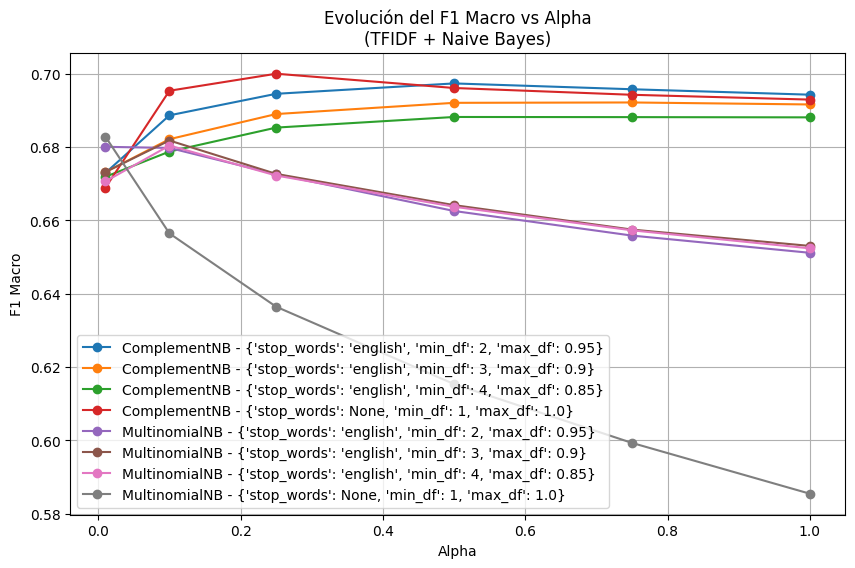

In [ ]:
import pandas as pd

# convertir dict a lista de filas
rows = []
for key, v in resultados.items():
    rows.append({
        "config": key,
        "modelo": v["nombre_modelo"],
        "alpha": v["alpha"],
        "f1_macro": v["f1_macro"],
        "vectorizador": str(v["vect_params"])
    })

df = pd.DataFrame(rows)

df["linea"] = df["modelo"] + " - " + df["vectorizador"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# agrupar por cada línea
for linea, grupo in df.groupby("linea"):
    grupo = grupo.sort_values("alpha")

    plt.plot(
        grupo["alpha"],
        grupo["f1_macro"],
        marker='o',
        label=linea
    )

plt.xlabel("Alpha")
plt.ylabel("F1 Macro")
plt.title("Evolución del F1 Macro vs Alpha\n(TFIDF + Naive Bayes)")
plt.legend()
plt.grid(True)

plt.show()

Se evaluaron distintas configuraciones de vectorización y modelos Naïve Bayes. En total, se entrenaron 48 confiugraciones diferentes y se seleccionó la mejor en función del F1-score macro sobre el conjunto de test.

Se analizó la evolución del F1-score macro en función del parámetro de suavizado alpha. Se observa que ComplementNB presenta un desempeño superior en todas las configuraciones, mientras que valores intermedios de alpha (0.5) logran, en promedio, los mejores desempeños. Además, la inclusión de preprocesamiento en el vectorizador impacta positivamente en el desempeño del modelo.

La mejor configuración obtenida corresponde a un modelo Complement Naïve Bayes con alpha=0.25, representación TF-IDF sin filtrado de términos (sin eliminación de stopwords y con min_df=1, max_df=1.0). Este resultado sugiere que, en este conjunto de datos, el uso de un vocabulario completo permite capturar información discriminativa adicional al incluir términos poco frecuentes y patrones de estilo lingüístico. A diferencia de MultinomialNB, el modelo ComplementNB es más robusto frente al ruido introducido por estos términos, lo que le permite beneficiarse de una representación más rica.

#### Punto 4

In [23]:
tfidfvect = TfidfVectorizer()
X_train = tfidfvect.fit_transform(newsgroups_train.data)

# Transposición
X_terms = X_train.T

# Diccionario palara/indice
word2idx = tfidfvect.vocabulary_
idx2word = {v: k for k, v in word2idx.items()}

# print(word2idx)

def palabras_similares(palabra, X_terms, word2idx, idx2word):
    idx = word2idx[palabra]
    print(f'Palabra: {palabra} - indice: {idx}')
    # Similitud de la palabra con todas las demás
    sims = cosine_similarity(X_terms[idx], X_terms)[0]

    # Ordenar de mayor a menor, solo 5 primeros
    top_idx = np.argsort(sims)[::-1][1:6]

    resultados = []
    for i in top_idx:
        resultados.append((idx2word[i], sims[i]))

    return resultados

In [24]:
# Palabras seleccionadas
palabras = ['religion','sports','engine','graphics','windows']

for palabra in palabras:
  resultados = palabras_similares(palabra, X_terms, word2idx, idx2word)
  print(f'Palabras similares a "{palabra}":')
  print(resultados)
  print('')

Palabra: religion - indice: 77274
Palabras similares a "religion":
[('religious', 0.24507616188432188), ('religions', 0.21164990102133843), ('categorized', 0.20391512948704682), ('purpsoe', 0.2007528102300327), ('crusades', 0.19870797843527088)]

Palabra: sports - indice: 84538
Palabras similares a "sports":
[('wip', 0.3698724021601651), ('rockin', 0.35986135934534424), ('pollute', 0.35986135934534424), ('jockeys', 0.35986135934534424), ('admittdly', 0.256547805810586)]

Palabra: engine - indice: 37287
Palabras similares a "engine":
[('guesser', 0.20150881545873378), ('mountings', 0.20150881545873378), ('tripmeter', 0.20150881545873378), ('rebuilt', 0.20101412803492238), ('undependable', 0.20054254272503194)]

Palabra: graphics - indice: 44261
Palabras similares a "graphics":
[('comp', 0.2575688868652991), ('grieggs', 0.202647023284772), ('3d', 0.19732053811336497), ('cfd', 0.1944820634941295), ('discused', 0.19442638638066093)]

Palabra: windows - indice: 96760
Palabras similares a "w

Los resultados muestran que, para palabras temáticamente específicas, la técnica recupera vecinos interpretables. Por ejemplo, 'windows' se asocia con 'dos', 'ms', 'microsoft' y 'nt', mientras que 'engine' recupera términos del dominio mecánico como 'tripmeter', 'rebuilt' y 'carburator'. De forma similar, 'religion' presenta cercanía con 'religious', 'religions' y 'crusades'. Sin embargo, no todos los términos producen resultados claros: en el caso de 'sports' aparecen vecinos poco interpretables, lo que evidencia que esta representación depende fuertemente de la especificidad del término y de la calidad del vocabulario.

Por lo tanto, la similaridad entre palabras obtenida por este método esta determinado por el contexto de cada documento y no siempre devuelve terminos interpretables.